# Compare market production methods (savegame)

Loads **format-2** `.pkl` snapshots from `analysis/savegame/notebooks/save_game_temp` (same pipeline as `compare_savegames_market.ipynb`): `locations` (already merged with region hierarchy), `buildings` (production methods per building), `market_goods`, etc.

**Recipe weights and PM slot groups** (food / drinks / packaging) are loaded from **`game_path` / `mod_path`** in your config via `BuildingData`—the same definitions as `production_method_comparison.ipynb`. Snapshots only store *which* PM each building uses; they do not embed recipe quantities.

Filters to one building type (default **`cookery`**, e.g. Prosper or Perish). Use `first_savegame` / `last_savegame` to slice snapshots (`last_savegame = 1` with `first_savegame = 0` for a single file).

**Global resource usage:** for the **latest** snapshot, three tables (**food** / **drinks** / **packaging**) list each trade **good** and **total_input** = sum over all cookery buildings of (recipe input parsed from `building_types` × buildings using that PM). PMs with no goods (e.g. well water, no packaging) contribute no rows.

**Global PM table:** counts how many cookery buildings use each `pp_cookery_*` method in the **latest** loaded snapshot (so totals are not multiplied when you load many time slices). Rows are grouped into **food**, **drinks**, and **packaging** to match the three `unique_production_methods` slots in the Prosper or Perish cookery building.

**Time-series plots:** when you load **multiple** snapshots, three line charts show how many buildings globally use each production method in the food, drink, and packaging slots over time (one line per `pp_cookery_*` method in that slot). The horizontal axis matches **`compare_savegames.ipynb`**: snapshot index 0, 1, … is labeled as **game years** (`start_year` 1337 + index × `years_per_snapshot` 5).

Pkls must include a **`buildings`** key (re-run the savegame watcher / processor with current ProsperPerishCalcs if yours were produced before that field existed).

In [64]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from IPython.display import display

from core.parser.path_resolver import PathResolver
from core.data.building_data import BuildingData
from analysis.building_levels.building_analysis import load_config
from analysis.savegame import (
    buildings_df_from_pkl,
    locations_df_from_pkl,
    resolve_pkl_dir,
)

pd.options.display.max_columns = None
pd.options.display.width = 200

In [65]:
# Cookery: three UPM slots from parsed mod `building_types` (same source as production_method_comparison)
config = load_config()
path_resolver = PathResolver(config["game_path"], config["mod_path"])
building_data = BuildingData(path_resolver)
building_data.load_all()

cookery_maps = building_data.cookery_pm_maps("cookery")

_COOKERY_PM_FOOD = cookery_maps.food
_COOKERY_PM_DRINKS = cookery_maps.drinks
_COOKERY_PM_PACKAGING = cookery_maps.packaging
_COOKERY_PM_GOOD_INPUTS = cookery_maps.pm_good_inputs


def _cookery_pm_category(pm: str) -> str:
    return cookery_maps.category(pm)


In [66]:
"""Load .pkl snapshots (format-2 with market_goods + buildings)."""

# None = auto (newest playthrough under save_game_temp), or set path to your playthrough folder
PKL_PATH = None  # e.g. ".../save_game_temp/<playthrough_id>"
first_savegame = 0
last_savegame = None  # None = all; use 1 with first_savegame=0 for one snapshot only

pkl_dir = resolve_pkl_dir(PKL_PATH)
pkl_files = sorted(pkl_dir.glob("*.pkl"), key=lambda p: p.stem)
if last_savegame is not None:
    pkl_files = pkl_files[first_savegame:last_savegame]
else:
    pkl_files = pkl_files[first_savegame:]

raw = {p.stem: pd.read_pickle(p) for p in pkl_files}

for label, payload in raw.items():
    if not isinstance(payload, dict) or "market_goods" not in payload:
        raise TypeError(
            f"{label}: expected format-2 pkl with 'market_goods'. Got {type(payload).__name__}"
        )
    if "buildings" not in payload:
        raise ValueError(
            f"{label}: pkl has no 'buildings' key. Regenerate snapshots with the current "
            "savegame processor / watcher (format-2 now includes buildings)."
        )

n_snap = len(raw)
print(f"Loaded {n_snap} snapshot(s) from {pkl_dir}")
print(f"Labels: {list(raw.keys())}")

Loaded 41 snapshot(s) from C:\Development\ProsperPerishCalcs\analysis\savegame\notebooks\save_game_temp\6c417b66_d3bd_40dc_8668_ecc75dc5c68d
Labels: ['20260321_200814', '20260321_200939', '20260321_201109', '20260321_201244', '20260321_201423', '20260321_201558', '20260321_201728', '20260321_201858', '20260321_202029', '20260321_202153', '20260321_202323', '20260321_202449', '20260321_202613', '20260321_202739', '20260321_202905', '20260321_203031', '20260321_203311', '20260321_203436', '20260321_203601', '20260321_203732', '20260321_203858', '20260321_204020', '20260321_204148', '20260321_204314', '20260321_204441', '20260321_204606', '20260321_204731', '20260321_204853', '20260321_205018', '20260321_205144', '20260321_205310', '20260321_205437', '20260321_205601', '20260321_205727', '20260321_205848', '20260321_210011', '20260321_210135', '20260321_210301', '20260321_210422', '20260321_210545', '20260321_210709']


In [67]:
# Building type to analyze (Prosper or Perish cookery); set to None to include all building types
BUILDING_SLUG = "cookery"

parts = []
for label, payload in raw.items():
    b = buildings_df_from_pkl(payload)
    if BUILDING_SLUG and "slug" in b.columns:
        b = b[b["slug"] == BUILDING_SLUG].copy()
    b["snapshot"] = label
    loc = locations_df_from_pkl(payload)
    scope = [c for c in ("region", "macro_region", "super_region") if c in loc.columns]
    if "location_id" not in loc.columns or not scope:
        raise ValueError(f"{label}: locations frame missing location_id or scope columns.")
    # Omit location `slug` so it does not collide with building `slug`
    loc_sub = loc[["location_id", *scope]].drop_duplicates(subset=["location_id"])
    merged = b.merge(loc_sub, on="location_id", how="left", suffixes=("", "_loc"))
    parts.append(merged)

enriched = pd.concat(parts, ignore_index=True) if parts else pd.DataFrame()
# if not enriched.empty:
#     display(enriched.head(20))
# else:
#     slug_msg = f"slug={BUILDING_SLUG!r}" if BUILDING_SLUG else "all slugs"
#     print(f"No matching buildings ({slug_msg}) in selected snapshot(s).")

In [68]:
# Global PM table (latest snapshot only)
if enriched.empty:
    pm_global = pd.DataFrame()
    print("No data for global PM counts.")
else:
    # Latest snapshot only: one world state, not N × duplicate buildings across time slices
    if "snapshot" in enriched.columns:
        _last_snap = sorted(enriched["snapshot"].astype(str).unique())[-1]
        _base = enriched[enriched["snapshot"] == _last_snap]
        print(f"Global PM counts use snapshot: {_last_snap}")
    else:
        _base = enriched

    pm_long = _base.explode("production_method_ids", ignore_index=True).rename(
        columns={"production_method_ids": "production_method"}
    )
    pm_long = pm_long[pm_long["production_method"].astype(str).str.startswith("pp_cookery_", na=False)]
    counts = pm_long["production_method"].value_counts()
    pm_global = counts.rename("building_uses").reset_index()
    pm_global.columns = ["production_method", "building_uses"]
    pm_global["category"] = pm_global["production_method"].map(_cookery_pm_category)
    _cat_order = {"food": 0, "drinks": 1, "packaging": 2, "other": 3}
    pm_global["_k"] = pm_global["category"].map(_cat_order)
    pm_global = (
        pm_global.sort_values(["_k", "building_uses", "production_method"], ascending=[True, False, True])
        .drop(columns=["_k"])
        .reset_index(drop=True)
    )
    display(pm_global)
    cat_totals = (
        pm_global.groupby("category", sort=False)["building_uses"]
        .sum()
        .reindex(["food", "drinks", "packaging", "other"], fill_value=0)
        .rename("sum_building_uses")
        .to_frame()
    )
    display(cat_totals)

Global PM counts use snapshot: 20260321_210709


,production_method,building_uses,category
0,pp_cookery_pemmican,910,food
1,pp_cookery_surstromming,335,food
2,pp_cookery_mutton_pottage,297,food
3,pp_cookery_saltfish_porridge,249,food
4,pp_cookery_fish_congee,167,food
5,pp_cookery_mutton_and_pease,150,food
6,pp_cookery_mediterranean_fish,131,food
7,pp_cookery_khichdi,82,food
8,pp_cookery_pozole,32,food
9,pp_cookery_labskaus,8,food


,sum_building_uses
category,
food,2361
drinks,2361
packaging,2361
other,0


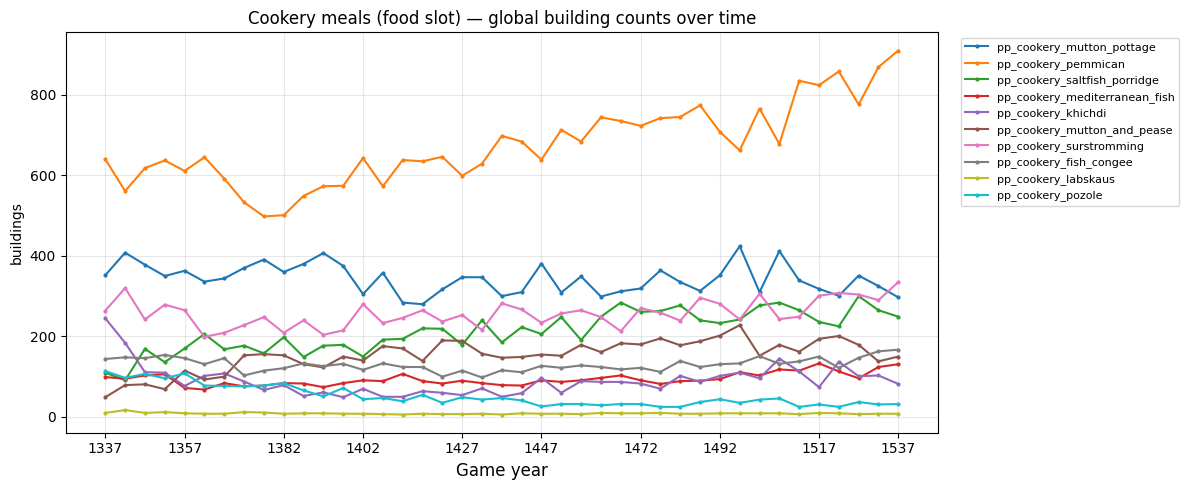

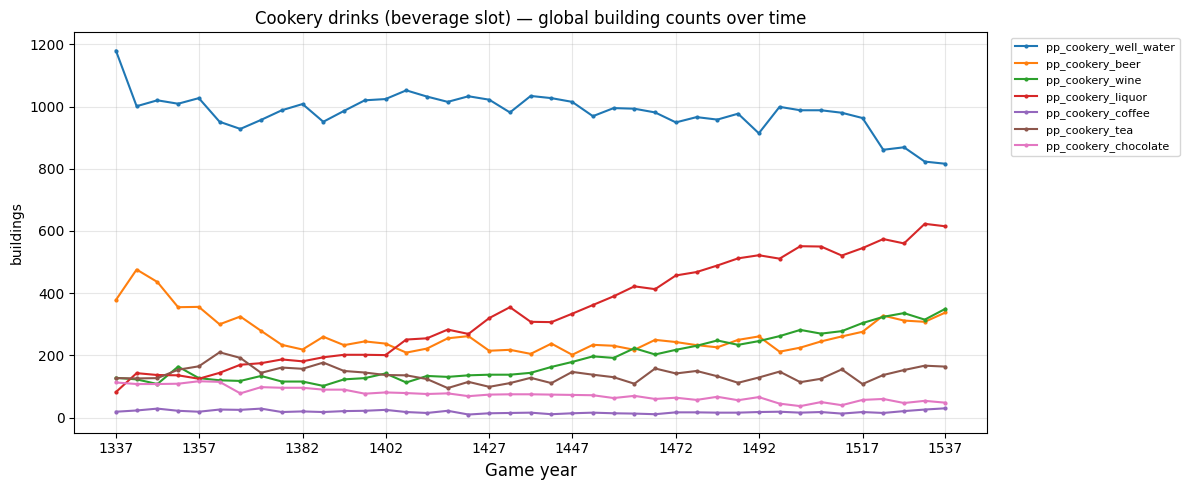

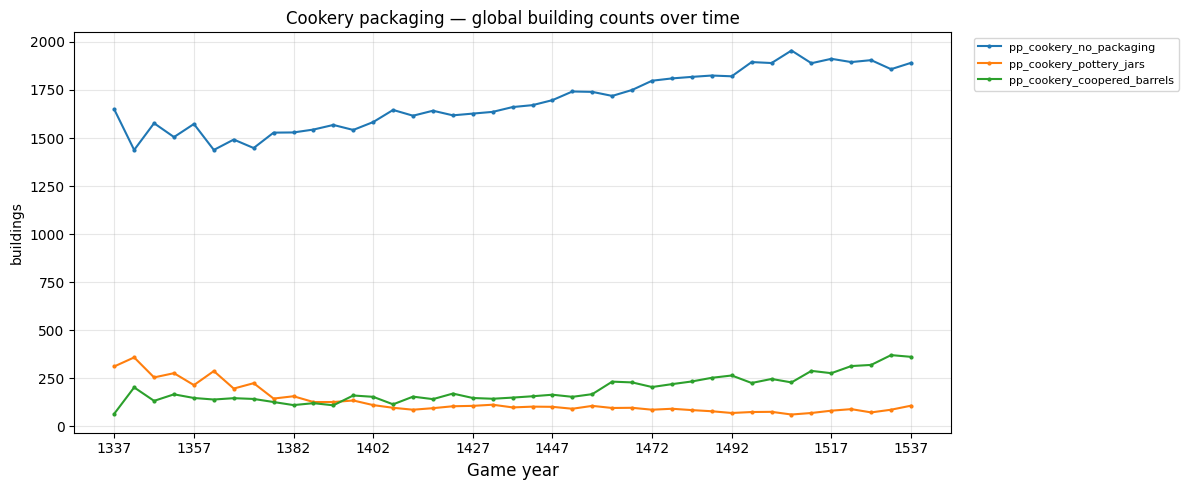

In [69]:
# Time series: global cookery PM counts per snapshot (meals / drinks / packaging slots)
if enriched.empty or "snapshot" not in enriched.columns:
    print("No time-series data (need non-empty enriched with snapshot).")
else:
    pm_ts = enriched.explode("production_method_ids", ignore_index=True).rename(
        columns={"production_method_ids": "production_method"}
    )
    pm_ts = pm_ts[pm_ts["production_method"].astype(str).str.startswith("pp_cookery_", na=False)]
    pm_ts["category"] = pm_ts["production_method"].map(_cookery_pm_category)
    pm_ts = pm_ts[pm_ts["category"] != "other"]
    if pm_ts.empty:
        print("No pp_cookery_* production methods to plot.")
    else:
        counts = (
            pm_ts.groupby(["snapshot", "category", "production_method"], sort=False)
            .size()
            .rename("n")
        )
        snap_order = sorted(enriched["snapshot"].astype(str).unique())
        # X-axis: same convention as compare_savegames.ipynb (snapshot index -> game year)
        years_per_snapshot = 5
        start_year = 1337  # EU5 start
        n_ticks = 10
        n = len(snap_order)
        x_pos = list(range(n))
        if n <= 1:
            tick_positions = list(range(n))
        elif n <= n_ticks:
            tick_positions = list(range(n))
        else:
            step = (n - 1) / (n_ticks - 1)
            tick_positions = [int(round(i * step)) for i in range(n_ticks)]
        tick_labels = [start_year + pos * years_per_snapshot for pos in tick_positions]

        _slot_titles = {
            "food": "Cookery meals (food slot) — global building counts over time",
            "drinks": "Cookery drinks (beverage slot) — global building counts over time",
            "packaging": "Cookery packaging — global building counts over time",
        }
        for cat in ("food", "drinks", "packaging"):
            try:
                sub = counts.xs(cat, level="category")
            except KeyError:
                print(f"Skip time-series plot: no rows for category {cat!r}.")
                continue
            wide = sub.unstack(level="production_method", fill_value=0)
            wide = wide.reindex(snap_order).fillna(0).astype(int)
            if wide.empty:
                print(f"Skip time-series plot: empty pivot for {cat!r}.")
                continue
            fig, ax = plt.subplots(figsize=(12, 5))
            for col in wide.columns:
                ax.plot(x_pos, wide[col].values, label=col, marker="o", markersize=2)
            ax.set_title(_slot_titles[cat])
            ax.set_ylabel("buildings")
            ax.set_xlabel("Game year", fontsize=12)
            ax.tick_params(axis="both", labelsize=10)
            ax.grid(True, axis="both", alpha=0.3, linestyle="-")
            ax.set_xticks(tick_positions)
            ax.set_xticklabels(tick_labels)
            ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
            fig.tight_layout()
            plt.show()

In [70]:
# Global trade-good input usage (latest snapshot), by slot category — recipe inputs from
# Parsed per-PM trade-good inputs (_COOKERY_PM_GOOD_INPUTS) × count of cookery buildings using each PM.
if enriched.empty:
    print("No data for global resource usage.")
else:
    if "snapshot" in enriched.columns:
        _last_snap = sorted(enriched["snapshot"].astype(str).unique())[-1]
        _base = enriched[enriched["snapshot"] == _last_snap]
        print(f"Global resource usage — snapshot {_last_snap}")
    else:
        _base = enriched
    ex = _base.explode("production_method_ids", ignore_index=True).rename(
        columns={"production_method_ids": "production_method"}
    )
    ex = ex[ex["production_method"].astype(str).str.startswith("pp_cookery_", na=False)]
    if ex.empty:
        print("No pp_cookery_* production methods in this slice.")
    else:
        pm_counts = ex["production_method"].value_counts()
        for cat in ("food", "drinks", "packaging"):
            totals = defaultdict(float)
            for pm, n in pm_counts.items():
                if _cookery_pm_category(pm) != cat:
                    continue
                for good, qty in _COOKERY_PM_GOOD_INPUTS.get(pm, {}).items():
                    totals[good] += float(n) * float(qty)
            if not totals:
                print(f"\n{cat}: no trade-good inputs (empty recipe or no buildings).")
                continue
            df = pd.DataFrame(
                sorted(totals.items(), key=lambda kv: -kv[1]),
                columns=["good", "total_input"],
            )
            df["total_input"] = df["total_input"].round(2)
            df.insert(0, "category", cat)
            print(f"\n--- {cat} ---")
            display(df)

Global resource usage — snapshot 20260321_210709

--- food ---


,category,good,total_input
0,food,livestock,4140.12
1,food,fish,3166.06
2,food,wild_game,1407.87
3,food,rice,821.70
4,food,millet,804.85
5,food,wheat,778.14
6,food,wool,532.50
7,food,legumes,482.42
8,food,fruit,455.00
9,food,salt,207.25



--- drinks ---


,category,good,total_input
0,drinks,liquor,1014.75
1,drinks,wine,700.00
2,drinks,beer,676.00
3,drinks,tea,200.08
4,drinks,cocoa,43.20
5,drinks,coffee,34.50



--- packaging ---


,category,good,total_input
0,packaging,furniture,325.8
1,packaging,pottery,302.4
